# EDA: Player Nations Analysis

Exploratory Data Analysis of FIFA players by nationality

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Load data
df = pd.read_csv('../data/FIFA23/FIFA23_official_data.csv')
print(f"Data loaded: {df.shape[0]} players")
print(df[['Name', 'Nationality', 'Overall', 'Age', 'Club']].head())

Data loaded: 17660 players
              Name Nationality  Overall  Age               Club
0      L. Goretzka     Germany       87   27  FC Bayern München
1  Bruno Fernandes    Portugal       86   27  Manchester United
2         M. Acuña   Argentina       85   30         Sevilla FC
3     K. De Bruyne     Belgium       91   31    Manchester City
4       N. Barella       Italy       86   25              Inter


Total unique nationalities: 161

Top 20 Countries by Number of Players:
Nationality
England                1531
Germany                1038
Spain                   990
France                  864
Argentina               843
Brazil                  539
Italy                   517
Netherlands             455
Uruguay                 417
Japan                   378
Venezuela               348
United States           345
Ecuador                 344
Portugal                338
Poland                  328
Turkey                  325
China PR                325
Sweden                  322
Republic of Ireland     308
Paraguay                302
Name: count, dtype: int64


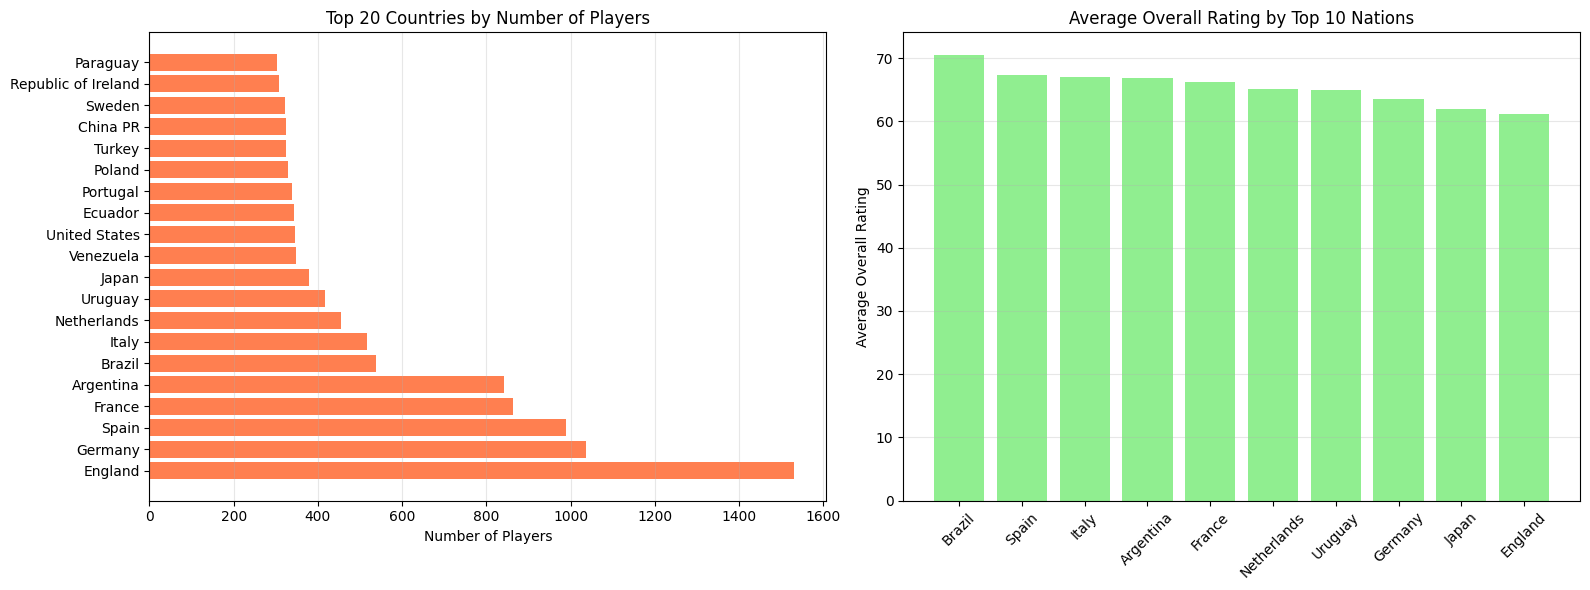

In [2]:
# Top nationalities
top_nations = df['Nationality'].value_counts().head(20)
print(f"Total unique nationalities: {df['Nationality'].nunique()}")
print("\nTop 20 Countries by Number of Players:")
print(top_nations)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot
axes[0].barh(top_nations.index, top_nations.values, color='coral')
axes[0].set_xlabel('Number of Players')
axes[0].set_title('Top 20 Countries by Number of Players')
axes[0].grid(axis='x', alpha=0.3)

# Average rating by top 10 nations
top_10_nations = df['Nationality'].value_counts().head(10).index
avg_overall = df[df['Nationality'].isin(top_10_nations)].groupby('Nationality')['Overall'].mean().sort_values(ascending=False)
axes[1].bar(range(len(avg_overall)), avg_overall.values, color='lightgreen')
axes[1].set_xticks(range(len(avg_overall)))
axes[1].set_xticklabels(avg_overall.index, rotation=45)
axes[1].set_ylabel('Average Overall Rating')
axes[1].set_title('Average Overall Rating by Top 10 Nations')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [3]:
# Count top-tier players per country (Overall >= 75)
top_players = df[df['Overall'] >= 75]
nation_counts = top_players['Nationality'].value_counts().reset_index()
nation_counts.columns = ['country', 'player_count']

print(f"\nTotal countries with elite players (≥75): {len(nation_counts)}")
print("\nTop 15 countries by elite player count:")
print(nation_counts.head(15))

# Choropleth world map
fig = px.choropleth(
    nation_counts,
    locations='country',
    locationmode='country names',
    color='player_count',
    color_continuous_scale='YlOrRd',
    title='Countries Producing the Most Top-Tier Players (Overall ≥ 75)',
    template='plotly_dark',
    labels={'player_count': 'Top Players'}
)
fig.update_layout(
    geo=dict(showframe=False, showcoastlines=True, projection_type='natural earth'),
    height=500
)
fig.show()

# Also show as bar for top 20 nations
top20 = nation_counts.head(20)
fig2 = px.bar(
    top20, x='country', y='player_count',
    color='player_count', color_continuous_scale='Reds',
    title='Top 20 Nations by Elite Player Count',
    template='plotly_dark',
    labels={'player_count': 'Elite Players', 'country': 'Country'}
)
fig2.update_layout(coloraxis_showscale=False, xaxis_tickangle=-45, height=500)
fig2.show()


Total countries with elite players (≥75): 95

Top 15 countries by elite player count:
        country  player_count
0         Spain           201
1        France           177
2        Brazil           171
3       England           140
4     Argentina           120
5       Germany           105
6         Italy           105
7      Portugal            79
8   Netherlands            61
9       Belgium            40
10      Uruguay            34
11       Mexico            32
12      Croatia            30
13     Colombia            29
14      Denmark            28


C:\Users\bprak\AppData\Local\Temp\ipykernel_26912\3489010289.py:11: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(
